# GCP2 Notes: KNN and Spatial Regionalization for GR4J

## Notebook purpose
This notebook implements two related regionalization workflows for estimating GR4J parameters for ungauged or withheld catchments:

1. **Spatial proximity regionalization** based on geographic distance between gauges.
2. **Descriptor-based KNN regionalization** based on similarity in catchment attributes.

The main goal is to test whether simple donor-based methods can recover the calibrated GR4J parameters `x1`, `x2`, `x3`, and `x4` for a hidden 30% of catchments. The notebook follows a train/test design so that method choices such as the number of neighbors are selected on the training subset only before being evaluated on unseen basins.

## What to expect in the notebook
Across the two code blocks below, the workflow:
- reads calibrated GR4J parameter results and supporting catchment information,
- filters to acceptable donor basins using an NSE threshold,
- splits basins into training and hidden test groups,
- tunes KNN settings using only the training portion,
- predicts GR4J parameters for the hidden test set,
- computes summary performance metrics, and
- produces diagnostic plots and spatial error visualizations.

## Documentation note
The code itself already contains internal comments and section headers. The added markdown in this GCP2 version explains **why each section exists**, **what enters and leaves each block**, and **how the pieces fit together** without modifying the original code.


## Section 1: Spatial proximity regionalization

### Purpose of this block
This first model assumes that **nearby catchments behave more similarly than distant ones**. Instead of using catchment descriptors, it identifies neighboring donor basins using latitude and longitude and transfers GR4J parameter information from those nearest basins.

### Main logic
This code block is organized into a full end-to-end workflow:

#### 1. User settings
The opening section defines all key inputs and analysis choices, including:
- the file containing calibrated GR4J results,
- the names of the ID and coordinate columns,
- the GR4J target parameters to regionalize,
- the NSE threshold used to retain acceptable basins,
- the test fraction for the hidden evaluation set,
- the output directory, and
- the candidate values of `k` and weighting strategy for the KNN donor search.

Keeping these settings near the top makes the notebook easier to adapt to updated files or revised experiments.

#### 2. Metric functions
Helper functions are defined for model evaluation. These provide consistent calculations for quantities such as:
- coefficient of determination,
- RMSE, and
- bias.

Placing these calculations in reusable functions avoids repeating the same formulas later in the notebook and makes the evaluation stage easier to follow.

#### 3. Spatial prediction function
A dedicated prediction function performs the core geographic KNN logic. Conceptually, it:
- converts coordinates into a format suitable for geographic distance calculations,
- computes pairwise separation between a target basin and donor basins,
- finds the `k` nearest donors,
- applies either uniform or distance-based weighting, and
- returns predicted GR4J parameters for the target basin.

This function is the heart of the spatial method because it translates map proximity into parameter estimates.

#### 4. Load and filter data
The dataset is then read, required columns are checked, and rows are filtered so that only catchments with acceptable calibration quality remain. This is important because weak donor basins could degrade regionalization performance if they are allowed into the training pool.

#### 5. Tune `k` using the training set only
The notebook splits the filtered catchments into:
- a **70% training set** used for donor selection and tuning, and
- a **30% hidden set** reserved for final evaluation.

Candidate values of `k` are tested only within the training data. This separation prevents information from the hidden test catchments from influencing model design.

#### 6. Final prediction on the hidden 30%
After the best neighbor setting is chosen, the code predicts `x1` through `x4` for each hidden catchment using only donors from the training subset.

#### 7. Compute final metrics
Performance is summarized parameter by parameter. This provides a direct way to compare how well the spatial approach transfers each GR4J parameter.

#### 8-9. Diagnostic plots
The final sections create:
- scatter plots comparing predicted and observed parameter values, and
- a map-oriented plot of test errors.

These plots help move beyond one-number summaries by showing whether errors are systematic, whether some parameters are harder to regionalize, and whether there are obvious spatial clusters of poor performance.

### Why this block matters
This section serves as a physically intuitive baseline. If a purely spatial donor approach performs reasonably well, it suggests that geographic closeness alone carries useful hydrologic information. If it performs poorly relative to descriptor-based methods, that supports the value of using basin attributes rather than location alone.


In [1]:
# ============================================================
# SPATIAL PROXIMITY REGIONALIZATION FOR GR4J
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import haversine_distances


# ============================================================
# 1. USER SETTINGS
# ============================================================

DATA_FILE = "gr4j_sceua_results.csv"   # change if needed
ID_COL = "catchment"
LAT_COL = "gauge_lat"
LON_COL = "gauge_lon"
NSE_COL = "NSE_cal"

TARGET_COLS = ["x1", "x2", "x3", "x4"]

MIN_NSE = 0.50
TEST_SIZE = 0.30
RANDOM_STATE = 42

OUTDIR = Path("gr4j_spatial_final")
OUTDIR.mkdir(exist_ok=True)

K_CANDIDATES = [1, 2, 3, 4, 5]
WEIGHTING = "distance"   # "distance" or "uniform"


# ============================================================
# 2. METRICS
# ============================================================

def paper_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) < 2:
        return np.nan
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.nanmean(y_pred - y_true))


# ============================================================
# 3. SPATIAL PREDICTION FUNCTION
# ============================================================

def spatial_predict(train_df, test_df, k=5, weighting="distance"):
    """
    Predict x1-x4 for test catchments using nearest training catchments
    based only on latitude/longitude.
    """

    # Haversine expects radians
    train_coords_rad = np.radians(train_df[[LAT_COL, LON_COL]].to_numpy(dtype=float))
    test_coords_rad = np.radians(test_df[[LAT_COL, LON_COL]].to_numpy(dtype=float))

    # Great-circle distances in radians
    dist_rad = haversine_distances(test_coords_rad, train_coords_rad)

    # Convert to km
    earth_radius_km = 6371.0088
    dist_km = dist_rad * earth_radius_km

    y_train = train_df[TARGET_COLS].to_numpy(dtype=float)

    predictions = np.zeros((len(test_df), len(TARGET_COLS)))

    for i in range(len(test_df)):
        d = dist_km[i]

        k_use = min(k, len(train_df))
        nn_idx = np.argpartition(d, kth=k_use - 1)[:k_use]

        nn_dist = d[nn_idx]
        nn_y = y_train[nn_idx]

        if weighting == "uniform":
            w = np.ones_like(nn_dist)
        elif weighting == "distance":
            w = 1.0 / (nn_dist + 1e-6)
        else:
            raise ValueError("weighting must be 'uniform' or 'distance'")

        pred = (nn_y * w[:, None]).sum(axis=0) / w.sum()
        predictions[i, :] = pred

    return predictions


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(DATA_FILE)

required_cols = [ID_COL, LAT_COL, LON_COL, NSE_COL] + TARGET_COLS
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

for col in required_cols:
    if col != ID_COL:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_cols).copy()

print(f"Rows before NSE filter: {len(df)}")

# Keep only acceptable donor/test catchments
df = df[df[NSE_COL] >= MIN_NSE].copy()

print(f"Rows after {NSE_COL} >= {MIN_NSE}: {len(df)}")

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training catchments: {len(train_df)}")
print(f"Hidden test catchments: {len(test_df)}")


# ============================================================
# 5. TUNE k ON TRAINING SET ONLY
# ============================================================

# simple internal split inside training to choose k
subtrain_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    shuffle=True
)

tuning_rows = []

for k in K_CANDIDATES:
    pred_val = spatial_predict(subtrain_df, val_df, k=k, weighting=WEIGHTING)

    row = {"k": k}
    r2s = []

    for j, target in enumerate(TARGET_COLS):
        y_true = val_df[target].to_numpy(dtype=float)
        y_pred = pred_val[:, j]
        this_r2 = paper_r2(y_true, y_pred)
        row[f"r2_{target}"] = this_r2
        r2s.append(this_r2)

    row["r2_mean"] = np.nanmean(r2s)
    tuning_rows.append(row)

tuning_df = pd.DataFrame(tuning_rows).sort_values("r2_mean", ascending=False).reset_index(drop=True)
tuning_df.to_csv(OUTDIR / "spatial_proximity_k_tuning.csv", index=False)

best_k = int(tuning_df.iloc[0]["k"])
print("\nBest k from internal tuning:", best_k)
print(tuning_df)


# ============================================================
# 6. FINAL PREDICTION ON HIDDEN 30%
# ============================================================

pred_test = spatial_predict(train_df, test_df, k=best_k, weighting=WEIGHTING)

pred_df = test_df[[ID_COL, LAT_COL, LON_COL, NSE_COL]].copy()

for j, target in enumerate(TARGET_COLS):
    pred_df[f"{target}_calibrated"] = test_df[target].to_numpy(dtype=float)
    pred_df[f"{target}_predicted"] = pred_test[:, j]
    pred_df[f"{target}_error"] = pred_df[f"{target}_predicted"] - pred_df[f"{target}_calibrated"]

pred_df.to_csv(OUTDIR / "spatial_proximity_hidden30_predictions.csv", index=False)


# ============================================================
# 7. METRICS
# ============================================================

metric_rows = []

for target in TARGET_COLS:
    y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
    y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

    metric_rows.append({
        "parameter": target,
        "r2_test": paper_r2(y_true, y_pred),
        "rmse_test": rmse(y_true, y_pred),
        "bias_test": bias(y_true, y_pred),
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df.loc[len(metrics_df)] = {
    "parameter": "mean_x1_x4",
    "r2_test": metrics_df["r2_test"].mean(),
    "rmse_test": metrics_df["rmse_test"].mean(),
    "bias_test": metrics_df["bias_test"].mean(),
}

metrics_df.to_csv(OUTDIR / "spatial_proximity_hidden30_metrics.csv", index=False)

print("\nHidden-30% metrics:")
print(metrics_df)


# ============================================================
# 8. SCATTER PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.ravel()

for ax, target in zip(axes, TARGET_COLS):
    y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
    y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

    r2 = paper_r2(y_true, y_pred)
    this_rmse = rmse(y_true, y_pred)
    this_bias = bias(y_true, y_pred)

    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))

    ax.scatter(y_true, y_pred, s=24, alpha=0.75)
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1)

    ax.set_title(target)
    ax.set_xlabel("Calibrated")
    ax.set_ylabel("Predicted")

    ax.text(
        0.05, 0.95,
        f"R² = {r2:.2f}\nRMSE = {this_rmse:.2f}\nBias = {this_bias:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
    )

plt.tight_layout()
plt.savefig(OUTDIR / "spatial_proximity_scatter.png", dpi=300)
plt.close()


# ============================================================
# 9. MAP OF TEST ERRORS
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

# mean absolute relative error across x1-x4
eps = 1e-9
rel_errors = []
for target in TARGET_COLS:
    rel_errors.append(
        np.abs(pred_df[f"{target}_predicted"] - pred_df[f"{target}_calibrated"]) /
        (np.abs(pred_df[f"{target}_calibrated"]) + eps)
    )

pred_df["mean_abs_relative_error"] = np.mean(rel_errors, axis=0)

sc = ax.scatter(
    pred_df[LON_COL],
    pred_df[LAT_COL],
    c=pred_df["mean_abs_relative_error"],
    s=28,
    alpha=0.85
)

plt.colorbar(sc, ax=ax, label="Mean absolute relative parameter error")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Spatial proximity test catchments (k={best_k})")
plt.tight_layout()
plt.savefig(OUTDIR / "spatial_proximity_error_map.png", dpi=300)
plt.close()

print(f"\nDone. Outputs saved in: {OUTDIR.resolve()}")

Rows before NSE filter: 666
Rows after NSE_cal >= 0.5: 423
Training catchments: 296
Hidden test catchments: 127

Best k from internal tuning: 3
   k     r2_x1     r2_x2     r2_x3     r2_x4   r2_mean
0  3  0.318744  0.219464  0.423678  0.351120  0.328251
1  4  0.319162  0.247161  0.397857  0.330993  0.323793
2  5  0.316113  0.243995  0.359606  0.310799  0.307628
3  2  0.301852  0.158038  0.438720  0.322333  0.305236
4  1  0.239460  0.222199  0.395294  0.325643  0.295649

Hidden-30% metrics:
    parameter   r2_test   rmse_test  bias_test
0          x1  0.084834  594.829653 -40.391523
1          x2  0.206774    1.692374  -0.129911
2          x3  0.401998   43.343155   0.825644
3          x4  0.124424    0.991919  -0.153135
4  mean_x1_x4  0.204508  160.214275  -9.962231

Done. Outputs saved in: /Users/kerrymannering/Downloads/gr4j_spatial_final


## Section 2: Descriptor-based KNN regionalization

### Purpose of this block
The second model replaces raw geographic distance with **similarity in catchment descriptors**. Instead of asking “which basin is closest on the map?”, it asks “which basin is most similar in climate, physiography, and other measured attributes?”

This is often more appropriate for regionalization because hydrologic behavior is not controlled by location alone.

### Main logic
This block again follows a complete workflow from input files to hidden-test evaluation.

#### 1. User settings
The code first defines:
- the calibrated parameter file,
- the descriptor file,
- the ID fields needed to merge those two sources,
- coordinate and NSE columns,
- the GR4J parameters to predict,
- the hidden test fraction and random seed,
- the output directory, and
- the requested pool of candidate descriptor variables.

These settings clearly separate assumptions about the data from the modeling steps that follow.

#### 2. Helper functions
Several utility functions are created to keep the workflow organized. These include:
- file-reading helpers,
- ID-cleaning logic to improve file matching,
- evaluation metric functions, and
- routines for scoring final predictions.

This modular structure makes the code easier to debug and easier to reuse in later notebooks.

#### 3. Load and merge data
The parameter results and descriptor table are read and then merged by catchment ID. This stage is especially important because regionalization quality depends on the integrity of the merged dataset. The code also converts descriptor columns to numeric form where possible and trims the working table to descriptors that are actually available.

#### 4. Internal tuning for KNN
The training-only tuning stage evaluates different KNN settings while carefully preventing leakage from the hidden test set. Within this section, the code:
- splits the data into training and hidden subsets,
- applies imputation so missing descriptor values can be handled consistently,
- scales descriptors so distance calculations are not dominated by variables with larger numeric ranges,
- compares candidate values of `k`,
- tests different weighting options, and
- may evaluate different Minkowski distance powers if included in the settings.

This is a critical step because KNN performance depends strongly on how similarity is measured.

#### 5. Final fit and prediction
Once tuning is complete, the selected KNN configuration is refit using the full 70% training subset and then used to predict the hidden 30% of catchments.

#### 6. Scatter plots
Predicted-versus-observed plots are generated for `x1`, `x2`, `x3`, and `x4`. These visual checks help reveal whether the model is:
- systematically overpredicting or underpredicting,
- performing well only within a narrow range, or
- failing to capture variability in a given parameter.

#### 7. Optional test error map
The notebook also includes a simple spatial view of test errors. Even though this is a descriptor-based method, mapping the results can still be useful because it shows whether poor predictions cluster in certain regions.

### Why this block matters
This method is typically more transferable than pure spatial proximity because it allows distant basins to act as good donors when they are physically similar. In the broader project, this section helps test whether descriptor similarity gives a stronger and more defensible basis for GR4J parameter regionalization.


In [2]:
# ============================================================
# DESCRIPTOR-BASED KNN REGIONALIZATION FOR GR4J
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor


# ============================================================
# 1. USER SETTINGS
# ============================================================

PARAMS_FILE = "gr4j_sceua_results.csv"   # your GR4J results file
DESCRIPTORS_FILE = "descriptors.csv"            # your descriptor file

PARAM_ID_COL = "catchment"
DESC_ID_COL = "gauge_id"   # change if needed

LAT_COL = "gauge_lat"
LON_COL = "gauge_lon"
NSE_COL = "NSE_cal"

TARGET_COLS = ["x1", "x2", "x3", "x4"]

MIN_NSE = 0.50
TEST_SIZE = 0.30
RANDOM_STATE = 42

OUTDIR = Path("gr4j_knn_final")
OUTDIR.mkdir(exist_ok=True)

# Same paper-mimic pool you used before
REQUESTED_DESCRIPTOR_POOL = [
    "p_mean",
    "p_seasonality",
    "frac_snow",
    "aridity",
    "high_prec_dur",
    "runoff_ratio",
    "baseflow_index",
    "q5",
    "q95",
    "hfd_mean",
    "geol_permeability",
    "soil_porosity",
    "slope_mean",
    "area_gages2",
]

K_CANDIDATES = [1, 2, 3, 4, 5]
WEIGHTING_OPTIONS = ["uniform", "distance"]
P_OPTIONS = [1, 2]   # 1=Manhattan, 2=Euclidean


# ============================================================
# 2. HELPERS
# ============================================================

def read_table(path, id_col):
    path = Path(path)
    if path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(path, dtype={id_col: str})
    return pd.read_csv(path, dtype={id_col: str})

def clean_gage_id(value):
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if s.endswith(".0"):
        s = s[:-2]
    s = "".join(ch for ch in s if ch.isdigit())
    if s == "":
        return np.nan
    return s.zfill(8)

def paper_r2(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1] ** 2)

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.nanmean((y_true - y_pred) ** 2)))

def bias(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.nanmean(y_pred - y_true))

def evaluate_predictions(pred_df, method_name):
    rows = []
    for target in TARGET_COLS:
        y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
        y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

        rows.append({
            "method": method_name,
            "parameter": target,
            "r2_test": paper_r2(y_true, y_pred),
            "rmse_test": rmse(y_true, y_pred),
            "bias_test": bias(y_true, y_pred),
        })

    rows.append({
        "method": method_name,
        "parameter": "mean_x1_x4",
        "r2_test": np.mean([r["r2_test"] for r in rows]),
        "rmse_test": np.mean([r["rmse_test"] for r in rows]),
        "bias_test": np.mean([r["bias_test"] for r in rows]),
    })

    return pd.DataFrame(rows)


# ============================================================
# 3. LOAD AND MERGE DATA
# ============================================================

params_df = read_table(PARAMS_FILE, PARAM_ID_COL)
desc_df = read_table(DESCRIPTORS_FILE, DESC_ID_COL)

params_df["_merge_id"] = params_df[PARAM_ID_COL].apply(clean_gage_id)
desc_df["_merge_id"] = desc_df[DESC_ID_COL].apply(clean_gage_id)

desc_df = desc_df.drop_duplicates("_merge_id")

df = params_df.merge(
    desc_df,
    on="_merge_id",
    how="inner",
    suffixes=("", "_desc"),
)

print(f"Rows in parameter file: {len(params_df)}")
print(f"Rows in descriptor file: {len(desc_df)}")
print(f"Rows after merge: {len(df)}")

required_cols = [PARAM_ID_COL, NSE_COL] + TARGET_COLS
for col in required_cols:
    if col != PARAM_ID_COL:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert descriptor pool columns to numeric if present
for col in REQUESTED_DESCRIPTOR_POOL:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

DESCRIPTOR_COLS = [c for c in REQUESTED_DESCRIPTOR_POOL if c in df.columns]
missing_descriptors = [c for c in REQUESTED_DESCRIPTOR_POOL if c not in df.columns]

print("\nUsing descriptor columns:")
print(DESCRIPTOR_COLS)

if missing_descriptors:
    print("\nMissing requested descriptors, skipped:")
    print(missing_descriptors)

if len(DESCRIPTOR_COLS) < 4:
    raise ValueError("Fewer than 4 descriptor columns were found.")

df = df.dropna(subset=required_cols).copy()
df = df[df[NSE_COL] >= MIN_NSE].copy()

print(f"\nCatchments after {NSE_COL} >= {MIN_NSE}: {len(df)}")

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training catchments: {len(train_df)}")
print(f"Hidden test catchments: {len(test_df)}")


# ============================================================
# 4. INTERNAL TUNING FOR KNN
#    tune k / weights / p using training data only
# ============================================================

subtrain_df, val_df = train_test_split(
    train_df,
    test_size=0.25,
    random_state=RANDOM_STATE,
    shuffle=True
)

X_subtrain = subtrain_df[DESCRIPTOR_COLS].copy()
X_val = val_df[DESCRIPTOR_COLS].copy()

y_subtrain = subtrain_df[TARGET_COLS].to_numpy(dtype=float)
y_val = val_df[TARGET_COLS].to_numpy(dtype=float)

# Impute + scale using subtrain only
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_subtrain_imp = imputer.fit_transform(X_subtrain)
X_val_imp = imputer.transform(X_val)

X_subtrain_scaled = scaler.fit_transform(X_subtrain_imp)
X_val_scaled = scaler.transform(X_val_imp)

tuning_rows = []

for k in K_CANDIDATES:
    for weights in WEIGHTING_OPTIONS:
        for p in P_OPTIONS:
            model = KNeighborsRegressor(
                n_neighbors=min(k, len(subtrain_df)),
                weights=weights,
                p=p,
                metric="minkowski",
            )

            model.fit(X_subtrain_scaled, y_subtrain)
            pred_val = model.predict(X_val_scaled)

            row = {
                "k": k,
                "weights": weights,
                "p": p,
            }

            r2s = []
            for j, target in enumerate(TARGET_COLS):
                this_r2 = paper_r2(y_val[:, j], pred_val[:, j])
                row[f"r2_{target}"] = this_r2
                r2s.append(this_r2)

            row["r2_mean"] = np.nanmean(r2s)
            tuning_rows.append(row)

tuning_df = pd.DataFrame(tuning_rows).sort_values("r2_mean", ascending=False).reset_index(drop=True)
tuning_df.to_csv(OUTDIR / "descriptor_knn_tuning.csv", index=False)

best_row = tuning_df.iloc[0]
best_k = int(best_row["k"])
best_weights = best_row["weights"]
best_p = int(best_row["p"])

print("\nBest descriptor-KNN settings:")
print(best_row)


# ============================================================
# 5. FINAL FIT ON FULL 70% TRAIN, PREDICT HIDDEN 30%
# ============================================================

X_train = train_df[DESCRIPTOR_COLS].copy()
X_test = test_df[DESCRIPTOR_COLS].copy()

y_train = train_df[TARGET_COLS].to_numpy(dtype=float)
y_test = test_df[TARGET_COLS].to_numpy(dtype=float)

final_imputer = SimpleImputer(strategy="median")
final_scaler = StandardScaler()

X_train_imp = final_imputer.fit_transform(X_train)
X_test_imp = final_imputer.transform(X_test)

X_train_scaled = final_scaler.fit_transform(X_train_imp)
X_test_scaled = final_scaler.transform(X_test_imp)

final_model = KNeighborsRegressor(
    n_neighbors=min(best_k, len(train_df)),
    weights=best_weights,
    p=best_p,
    metric="minkowski",
)

final_model.fit(X_train_scaled, y_train)
pred_test = final_model.predict(X_test_scaled)

pred_df = test_df[["_merge_id", PARAM_ID_COL, NSE_COL]].copy()

if LAT_COL in test_df.columns:
    pred_df[LAT_COL] = test_df[LAT_COL].to_numpy()
if LON_COL in test_df.columns:
    pred_df[LON_COL] = test_df[LON_COL].to_numpy()

for j, target in enumerate(TARGET_COLS):
    pred_df[f"{target}_calibrated"] = y_test[:, j]
    pred_df[f"{target}_predicted"] = pred_test[:, j]
    pred_df[f"{target}_error"] = pred_test[:, j] - y_test[:, j]

pred_df.to_csv(OUTDIR / "descriptor_knn_hidden30_predictions.csv", index=False)

metrics_df = evaluate_predictions(pred_df, "DescriptorKNN")
metrics_df.to_csv(OUTDIR / "descriptor_knn_hidden30_metrics.csv", index=False)

print("\nHidden-30% metrics:")
print(metrics_df)


# ============================================================
# 6. SCATTER PLOTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
axes = axes.ravel()

for ax, target in zip(axes, TARGET_COLS):
    y_true = pred_df[f"{target}_calibrated"].to_numpy(dtype=float)
    y_pred = pred_df[f"{target}_predicted"].to_numpy(dtype=float)

    r2 = paper_r2(y_true, y_pred)
    this_rmse = rmse(y_true, y_pred)
    this_bias = bias(y_true, y_pred)

    low = min(np.min(y_true), np.min(y_pred))
    high = max(np.max(y_true), np.max(y_pred))

    ax.scatter(y_true, y_pred, s=24, alpha=0.75)
    ax.plot([low, high], [low, high], linestyle="--", linewidth=1)

    ax.set_title(target)
    ax.set_xlabel("Calibrated")
    ax.set_ylabel("Predicted")

    ax.text(
        0.05, 0.95,
        f"R² = {r2:.2f}\nRMSE = {this_rmse:.2f}\nBias = {this_bias:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=9,
        bbox=dict(facecolor="white", edgecolor="gray", alpha=0.85)
    )

plt.tight_layout()
plt.savefig(OUTDIR / "descriptor_knn_scatter.png", dpi=300)
plt.close()


# ============================================================
# 7. OPTIONAL: SIMPLE TEST ERROR MAP
# ============================================================

if LAT_COL in pred_df.columns and LON_COL in pred_df.columns:
    fig, ax = plt.subplots(figsize=(8, 5))

    eps = 1e-9
    rel_errors = []
    for target in TARGET_COLS:
        rel_errors.append(
            np.abs(pred_df[f"{target}_predicted"] - pred_df[f"{target}_calibrated"]) /
            (np.abs(pred_df[f"{target}_calibrated"]) + eps)
        )

    pred_df["mean_abs_relative_error"] = np.mean(rel_errors, axis=0)

    sc = ax.scatter(
        pred_df[LON_COL],
        pred_df[LAT_COL],
        c=pred_df["mean_abs_relative_error"],
        s=28,
        alpha=0.85
    )
    plt.colorbar(sc, ax=ax, label="Mean absolute relative parameter error")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"Descriptor-KNN test catchments (k={best_k}, weights={best_weights}, p={best_p})")
    plt.tight_layout()
    plt.savefig(OUTDIR / "descriptor_knn_error_map.png", dpi=300)
    plt.close()

print(f"\nDone. Outputs saved in: {OUTDIR.resolve()}")

Rows in parameter file: 666
Rows in descriptor file: 671
Rows after merge: 666

Using descriptor columns:
['p_mean', 'p_seasonality', 'frac_snow', 'aridity', 'high_prec_dur', 'runoff_ratio', 'baseflow_index', 'q5', 'q95', 'hfd_mean', 'geol_permeability', 'soil_porosity', 'slope_mean', 'area_gages2']

Catchments after NSE_cal >= 0.5: 423
Training catchments: 296
Hidden test catchments: 127

Best descriptor-KNN settings:
k                 2
weights    distance
p                 1
r2_x1      0.633256
r2_x2       0.56182
r2_x3      0.551821
r2_x4      0.389792
r2_mean    0.534173
Name: 0, dtype: object

Hidden-30% metrics:
          method   parameter   r2_test   rmse_test  bias_test
0  DescriptorKNN          x1  0.526477  404.031010 -24.770235
1  DescriptorKNN          x2  0.262391    1.633090  -0.167195
2  DescriptorKNN          x3  0.492465   40.340737   1.915535
3  DescriptorKNN          x4  0.193117    0.951900  -0.121855
4  DescriptorKNN  mean_x1_x4  0.368613  111.739184  -5.785937



## Interpretation guide

When reviewing the outputs from both methods, the main questions to ask are:

1. Which method gives stronger hidden-test performance for each GR4J parameter?
2. Are some parameters consistently easier to regionalize than others?
3. Do scatter plots suggest unbiased transfer, or do they reveal systematic error?
4. Does the map suggest any regional pattern in failures?
5. Does descriptor-based similarity outperform pure geographic closeness enough to justify the additional complexity?

These are the kinds of interpretation points that connect the code back to the hydrologic objective of the project.


# Plots

<h1><b>Model Plots</b></h1>

<h2><b>Descriptor-Based KNN</b></h2>

<h3><b>descriptor knn error map</b></h3>

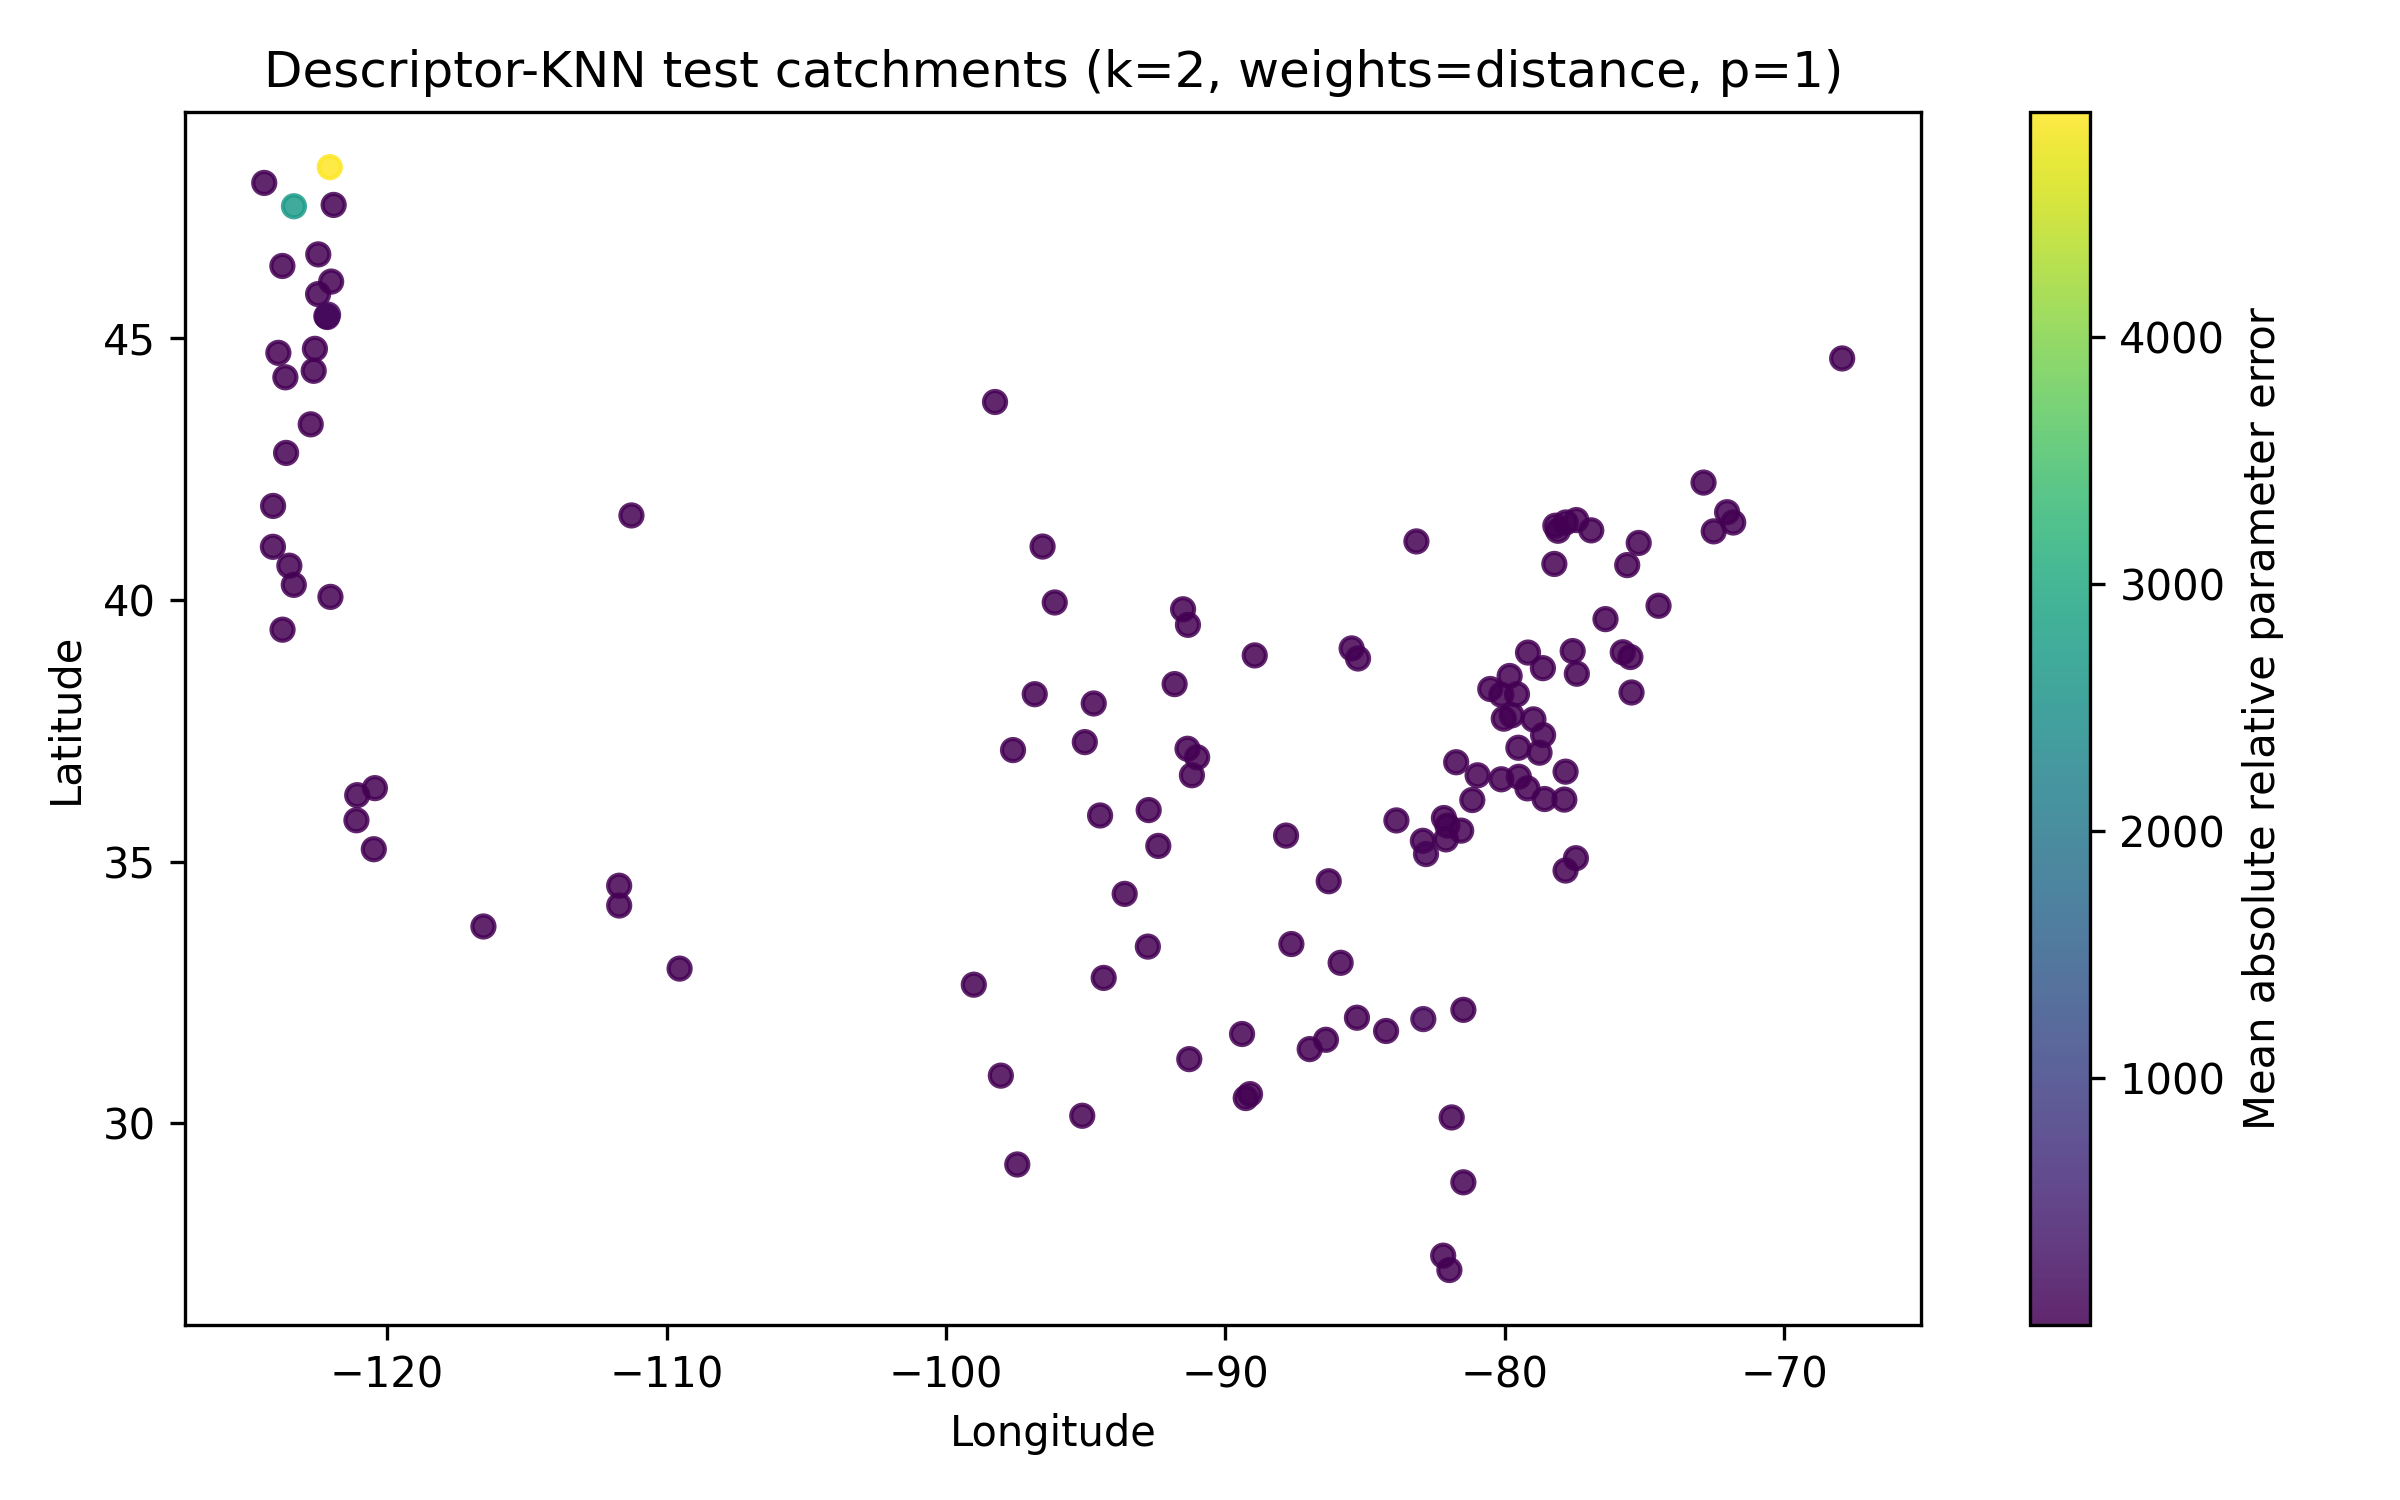

<h3><b>descriptor knn scatter</b></h3>

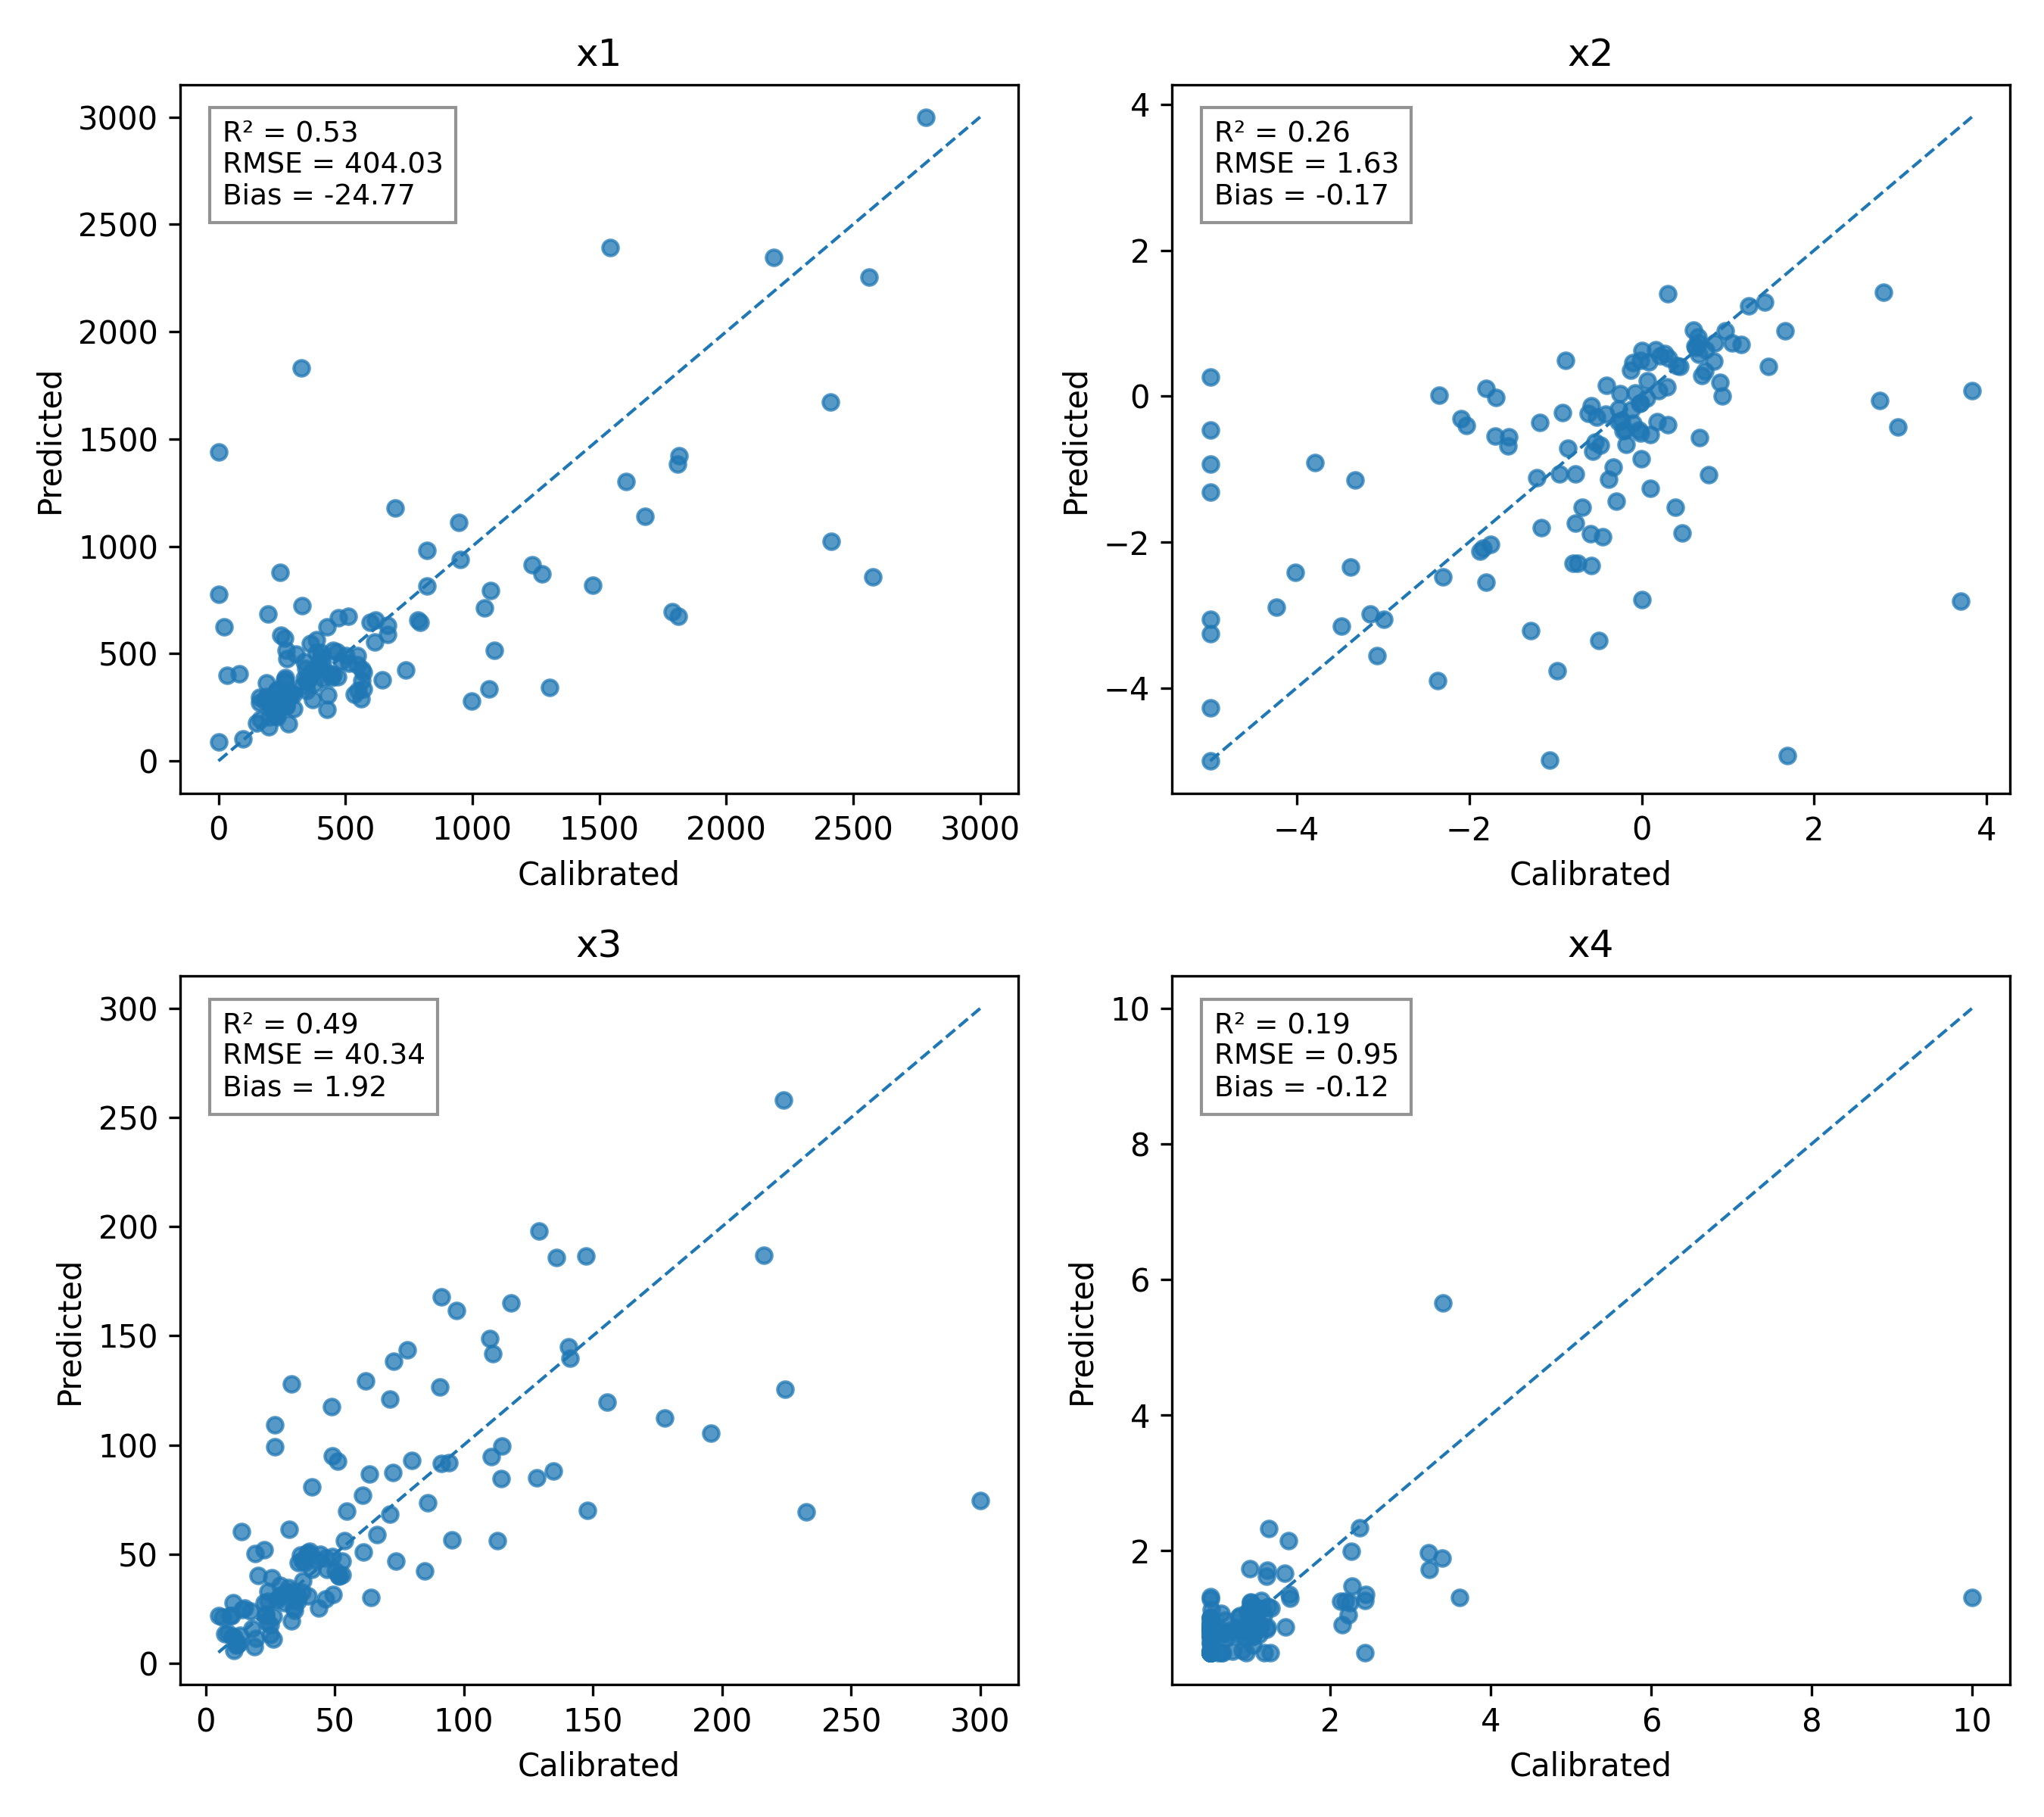

<h2><b>Spatial Proximity</b></h2>

<h3><b>spatial proximity error map</b></h3>

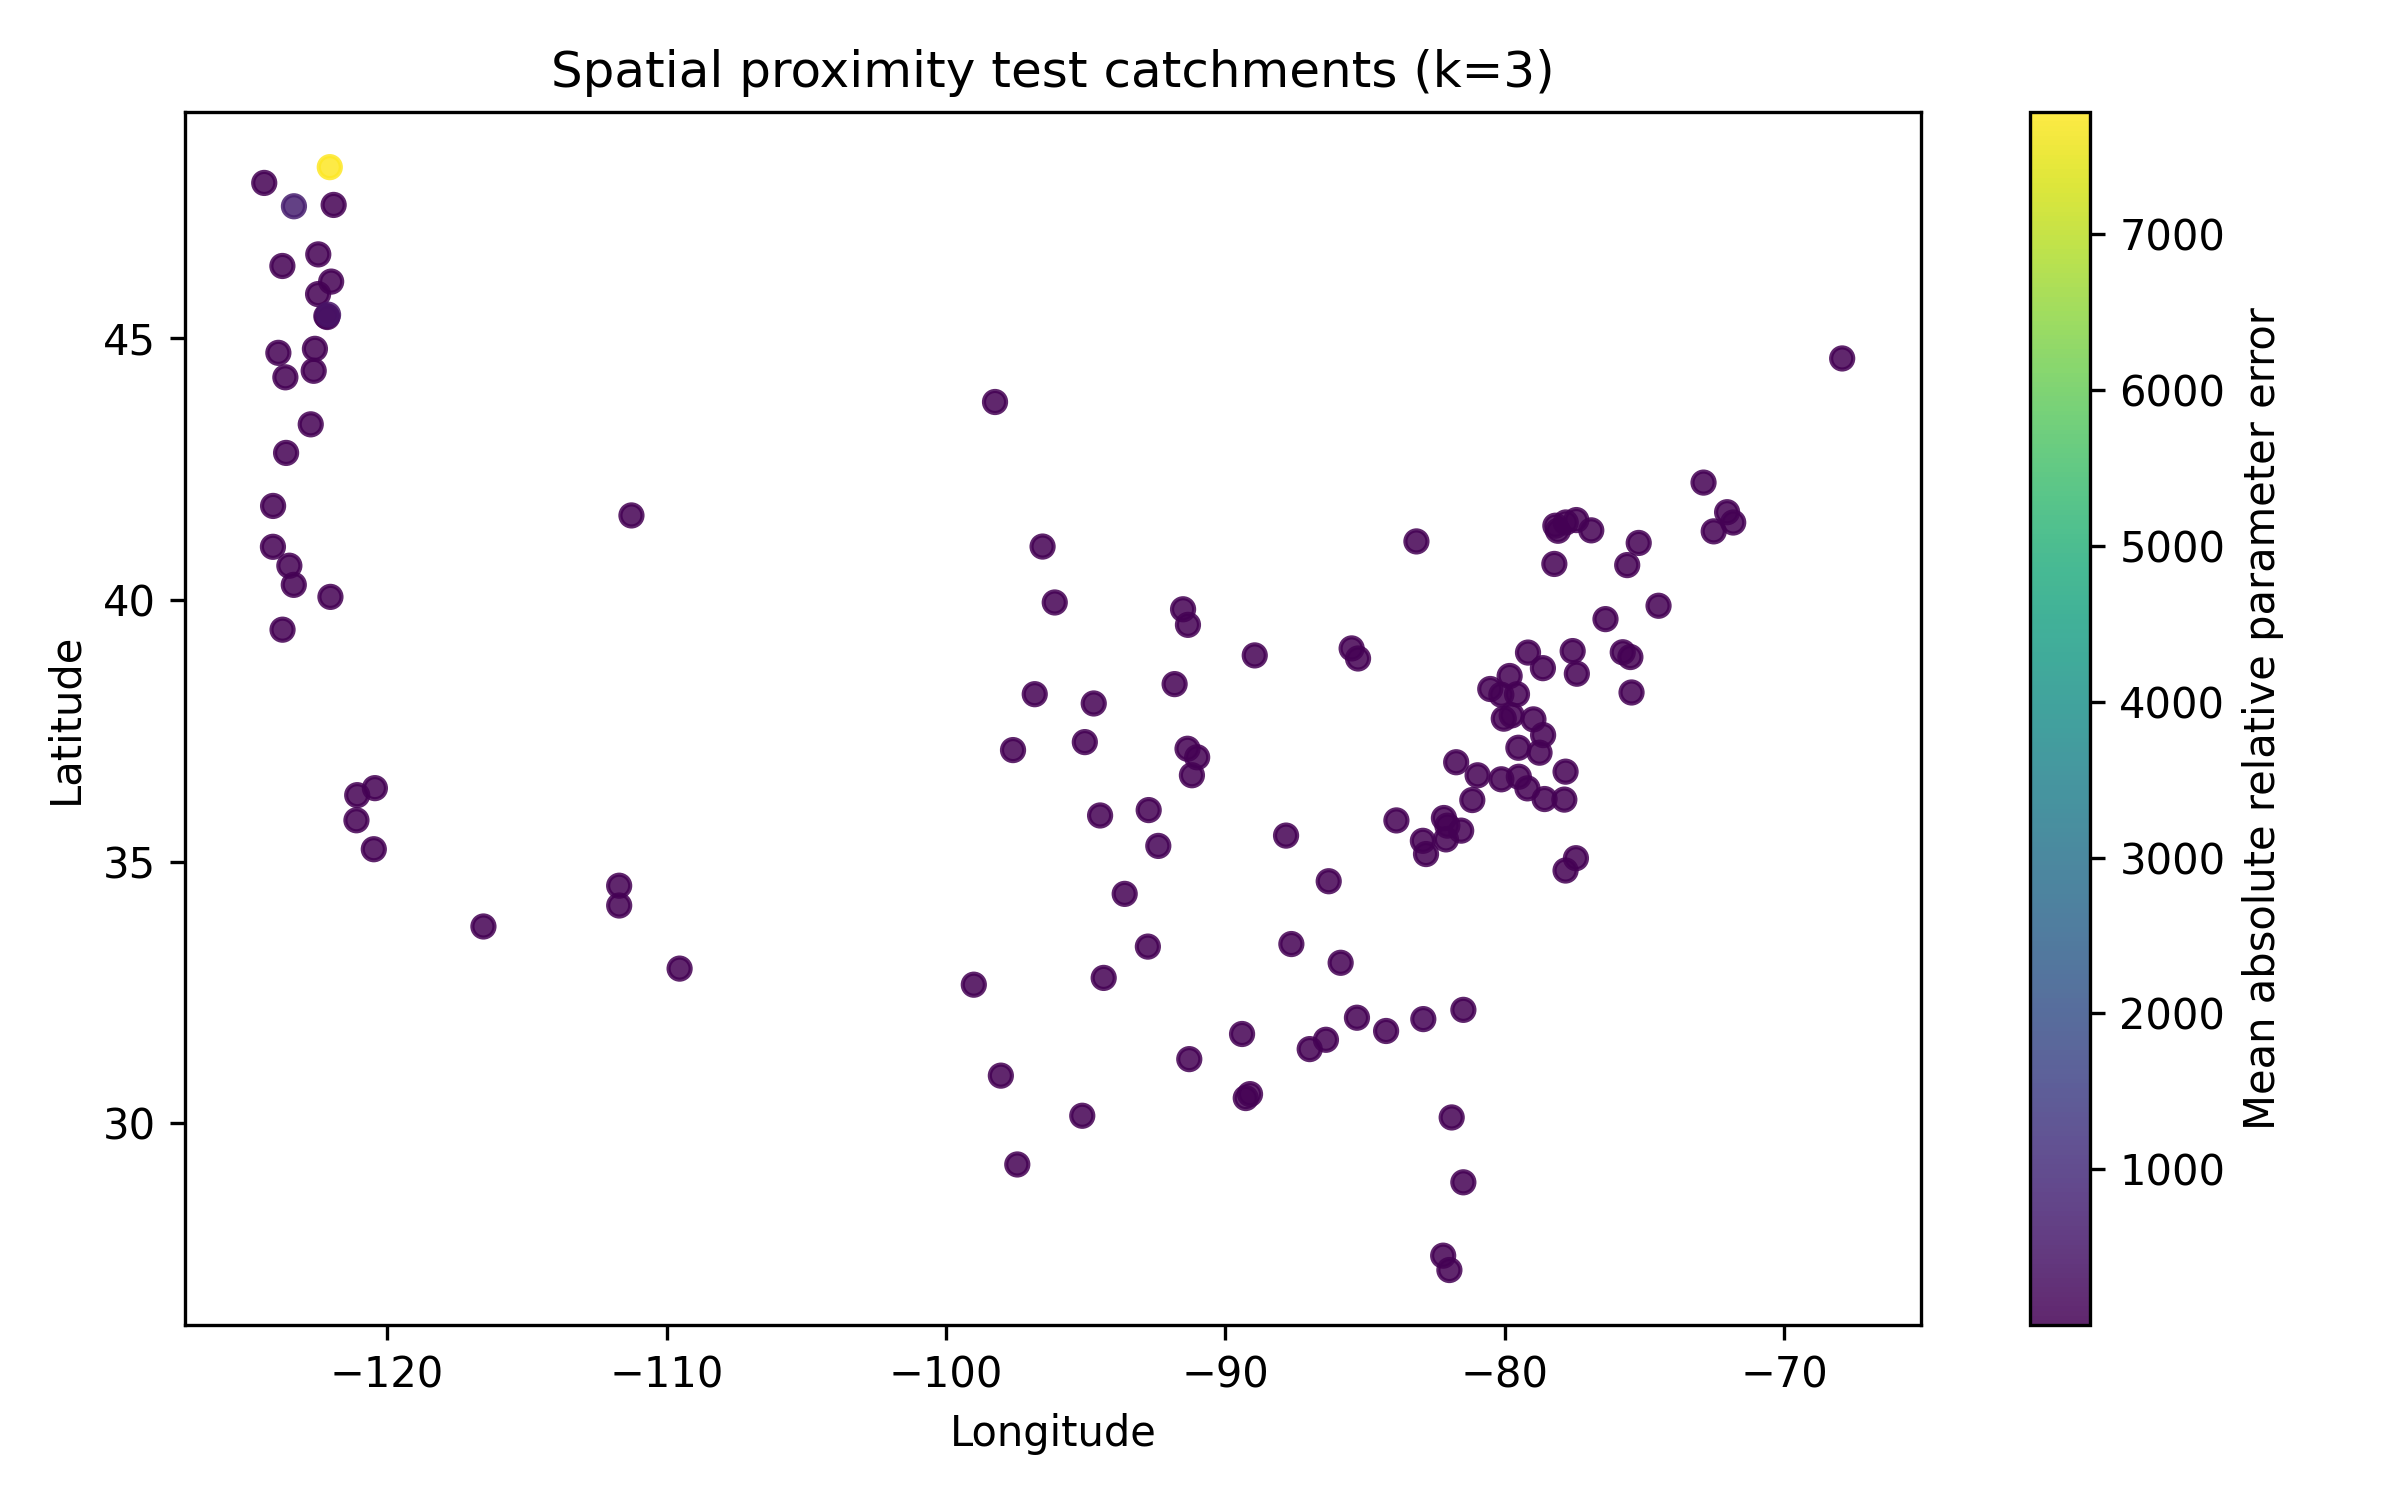

<h3><b>spatial proximity scatter</b></h3>

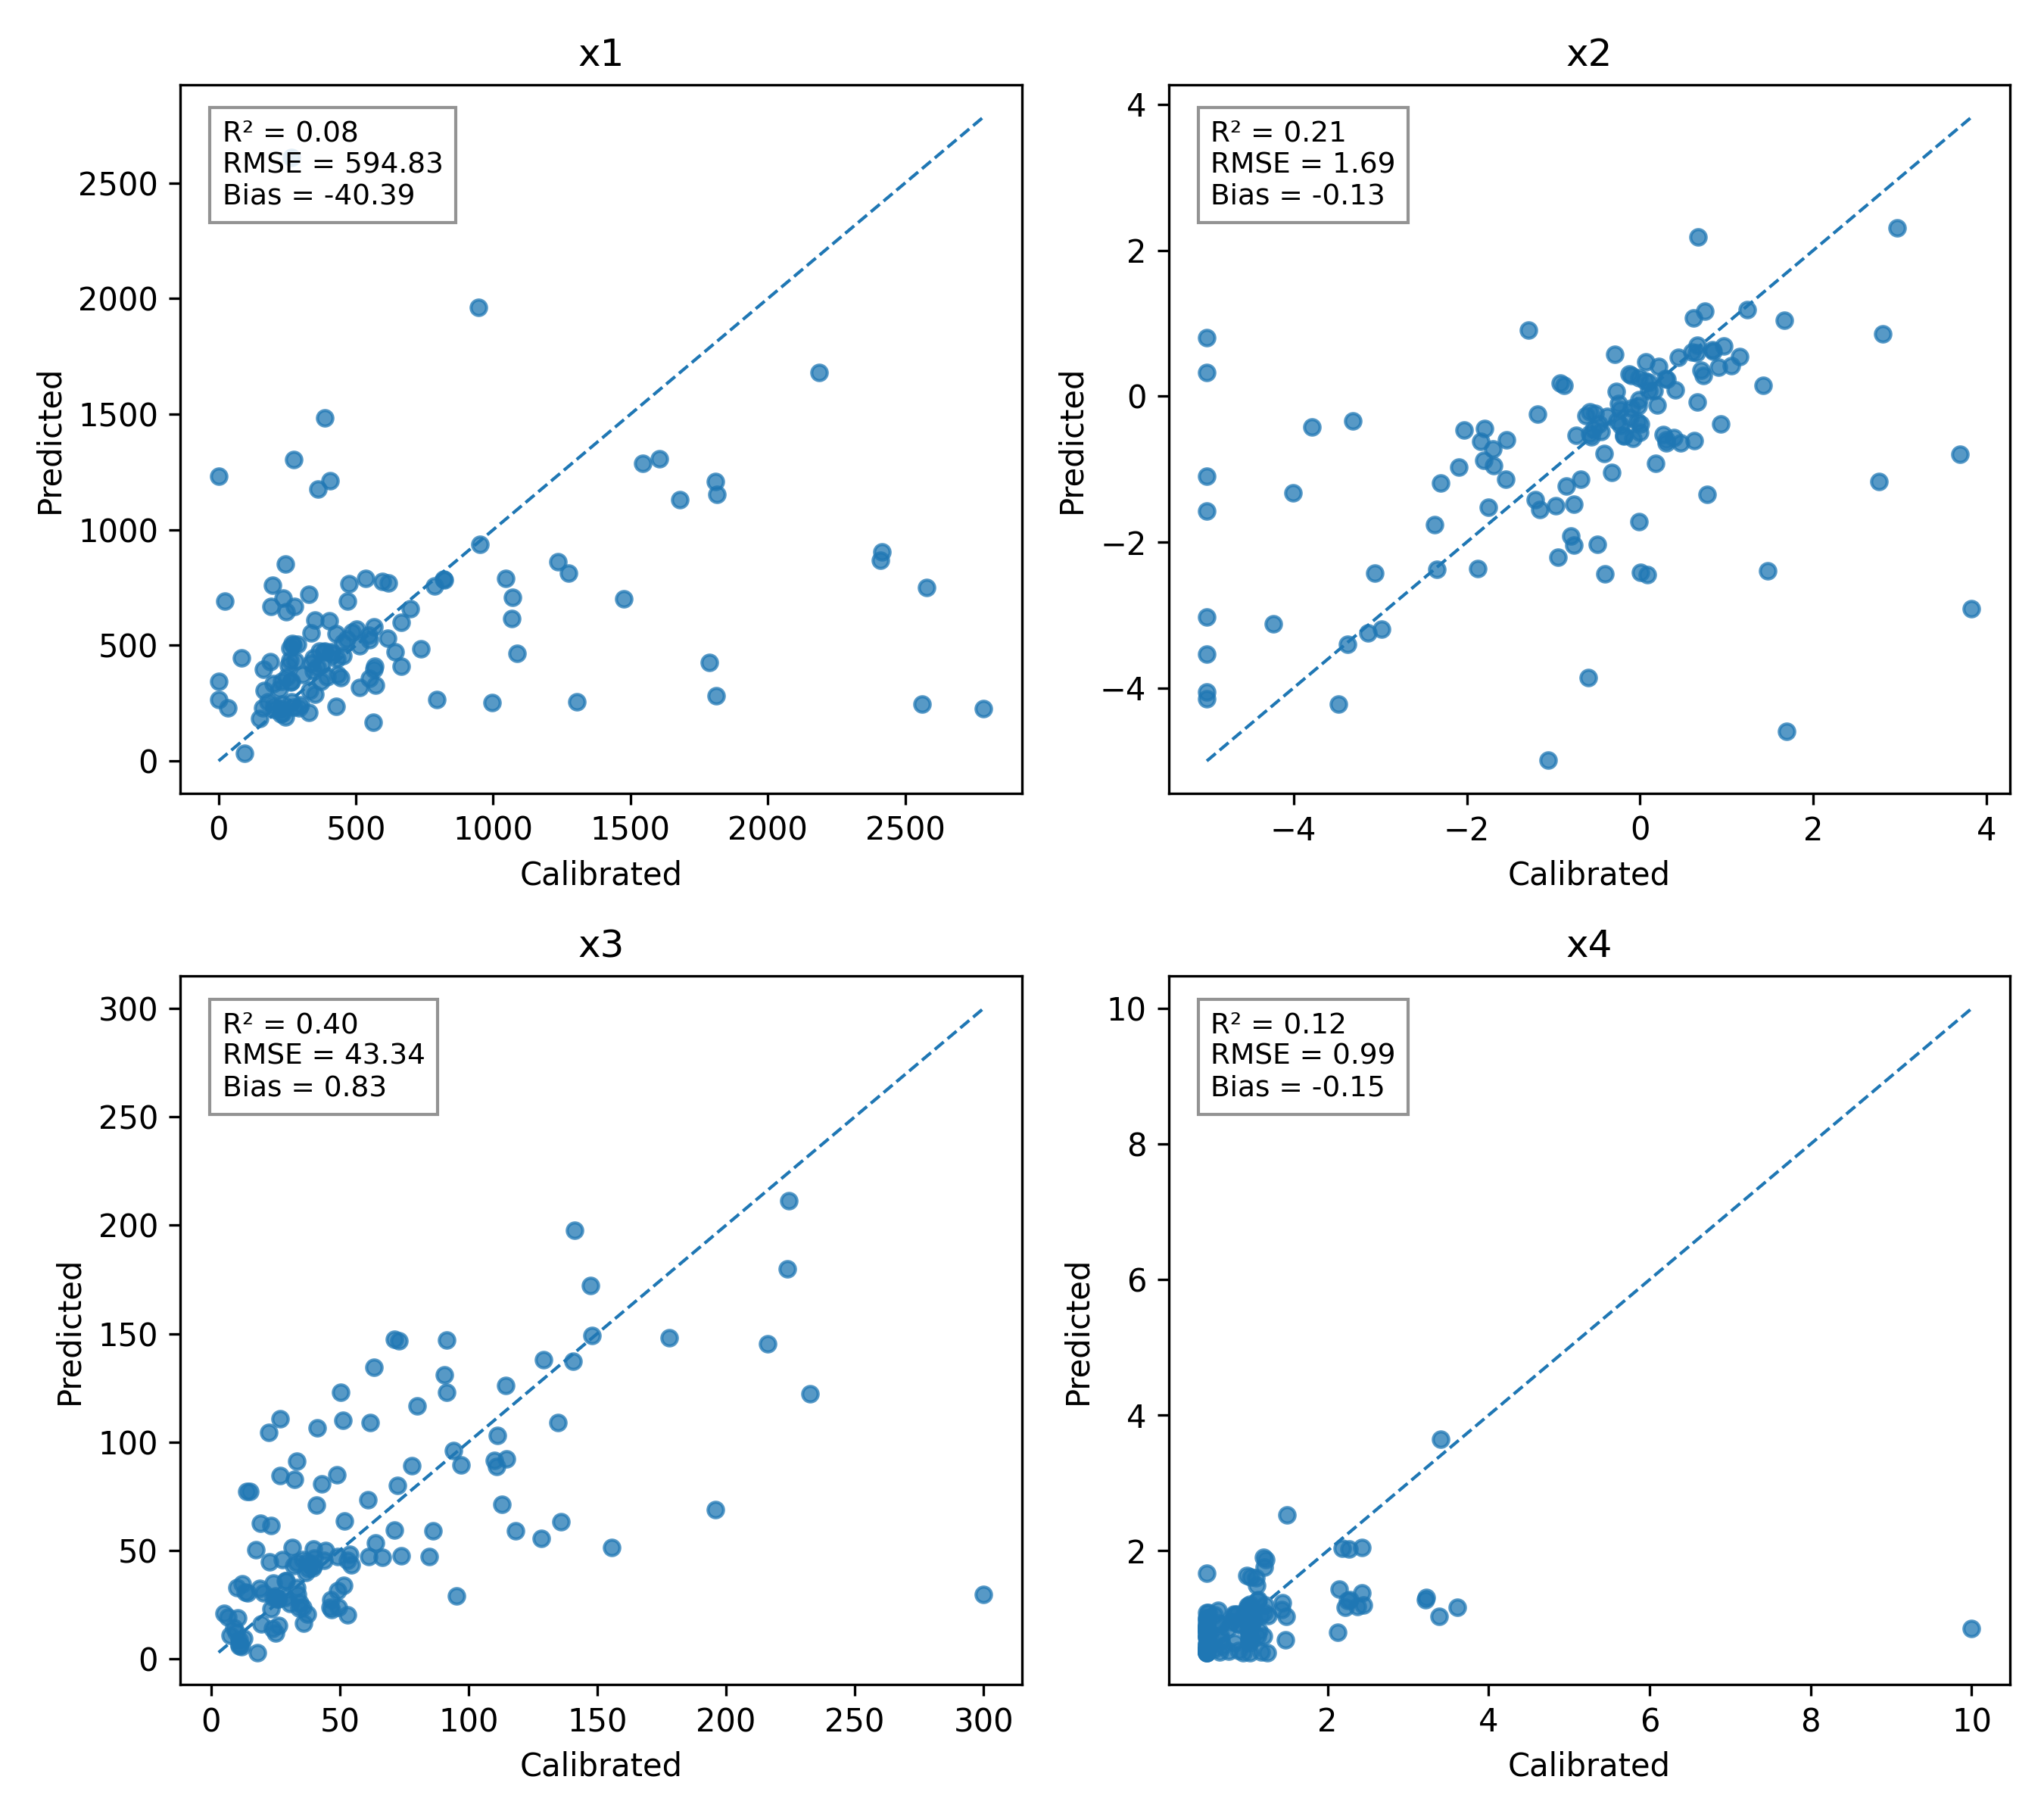

In [5]:
from IPython.display import display, Markdown, Image
from pathlib import Path

KNN_DIR = Path("gr4j_knn_final")
SPATIAL_DIR = Path("gr4j_spatial_final")

def show_title(text, level=2):
    display(Markdown(f"<h{level}><b>{text}</b></h{level}>"))

def show_all_pngs(folder, section_title, width=1100):
    show_title(section_title, level=2)

    png_files = sorted(folder.glob("*.png"))
    if not png_files:
        display(Markdown(f"**No PNG files found in `{folder}`**"))
        return

    for fp in png_files:
        pretty_name = fp.stem.replace("_", " ")
        show_title(pretty_name, level=3)
        display(Image(filename=str(fp), width=width))

show_title("Model Plots", level=1)

show_all_pngs(KNN_DIR, "Descriptor-Based KNN")
show_all_pngs(SPATIAL_DIR, "Spatial Proximity")